# MLFlow Project — Data Analysis, Prediction & Clustering

# Imports and Reading Data

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pylab as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import joblib

In [2]:
df = pd.read_csv("./Data/data.csv")


# Step 1 Observe the data
- Show shape, first rows, statistics
- Goal: "Let me see what I'm working with"

In [3]:
print(df.shape)

(100, 3)


In [4]:
df.columns

Index(['A', 'B', 'Y'], dtype='object')

In [5]:
print(df.head())

          A   B   Y
0  1.293911  13  15
1  5.838877  24  33
2  2.346042  31  35
3  0.477911  10  11
4  1.534273  20  23


In [6]:
print(df.tail())

           A   B   Y
95  1.004920  12  14
96  2.863552  28  33
97  1.284802  12  14
98  7.333209  28  39
99  2.623081  20  24


In [7]:
print(df.describe())

                A           B           Y
count  100.000000  100.000000  100.000000
mean     3.112698   21.100000   26.280000
std      2.303526    7.888747    8.936454
min      0.004248   10.000000   11.000000
25%      1.457042   13.750000   20.000000
50%      2.536842   20.000000   24.000000
75%      4.726967   26.000000   32.250000
max      8.951167   40.000000   50.000000


In [8]:
print(df.isnull().sum())

A    0
B    0
Y    0
dtype: int64


Insights :
Based on the data , here is what i found: 
- A ranges from 0 to 9
- B ranges from 10 to 40
- Y ranges from 11 to 50

# Step 2  Visualize relationships
## Analyze the data (correlations)

- Draw pairplot and heatmap
- Goal: Understand which columns are related to each other  


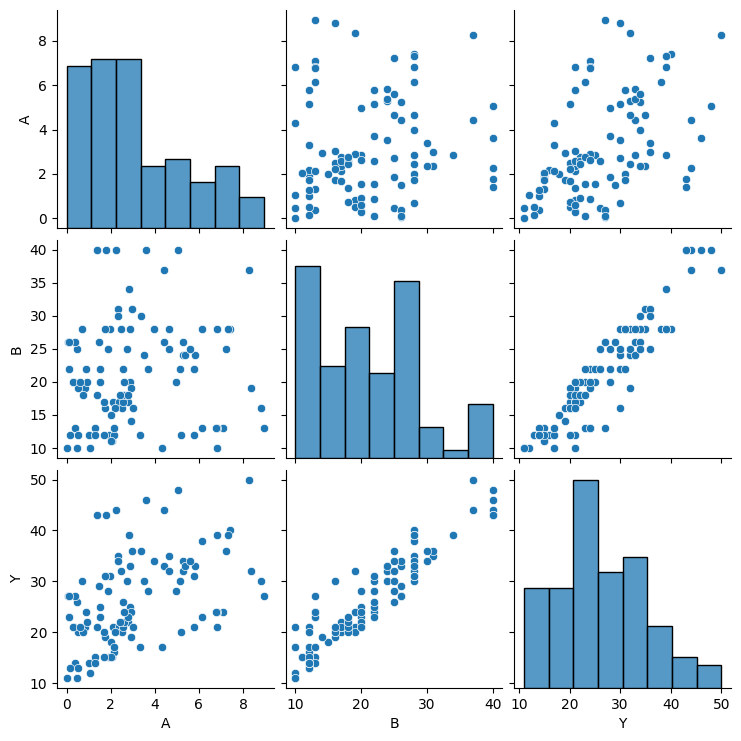

In [9]:
sns.pairplot(df)

## Correlation

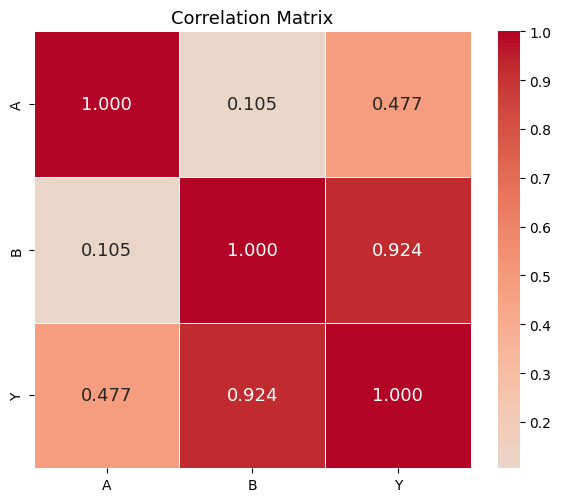

Correlation matrix:


,A,B,Y
A,1.0000,0.1051,0.4769
B,0.1051,1.0000,0.9236
Y,0.4769,0.9236,1.0000


In [10]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 13})
plt.title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

print("Correlation matrix:")
display(corr.round(4))

insights: 
- Correlation between A and B: 0.105 (Very weak).
- Correlation between B and Y: 0.924 (Very strong).
- Correlation between A and Y: 0.477 (Moderate).
- So predicting B from A will probably not work very well, but you can still test it.

# Step 3 Answer the following questions:
- Can we predict B based on A?
    - No. The correlation is extremely low, and the R2 score is only 0.03. They are nearly independent.
- Can we predict Y based on B? 
    - Yes. There is a strong linear relationship (R2 approx 0.84).
- Can we predict Y based on A and B?  
    - Yes, almost perfectly. Using both variables gives an R2 approx 0.99, suggesting Y is a direct function of A and B.

In [11]:
# Question 1: Predict B based on A
X = df[['A']]
y = df['B']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
print("1. Can we predict B based on A?")
print(f"   R² = {r2:.4f} | MAE = {mae:.2f}")

# Question 2: Predict Y based on B
X = df[['B']]
y = df['Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
print("\n2. Can we predict Y based on B?")
print(f"   R² = {r2:.4f} | MAE = {mae:.2f}")

# Question 3: Predict Y based on A and B
X = df[['A', 'B']]
y = df['Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
print("\n3. Can we predict Y based on A and B?")
print(f"   R² = {r2:.4f} | MAE = {mae:.2f}")

1. Can we predict B based on A?
   R² = 0.0304 | MAE = 6.29

2. Can we predict Y based on B?
   R² = 0.8422 | MAE = 3.35

3. Can we predict Y based on A and B?
   R² = 0.9991 | MAE = 0.25


# Step 4 Propose prediction models for Y (compare the different models, their scores, etc.)
- In this test I used 6 different models
- Compare which one is best
-  Goal: Find the most accurate way to predict Y

#### Result is "Linear Regression"

In [12]:
X = df[['A', 'B']]
y = df['Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    pred = model.predict(X_test)
    
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    
    results.append({
        'Model': name,
        'R²': round(r2, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4)
    })

# Display comparison table
results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

            Model     R²   RMSE    MAE
Linear Regression 0.9991 0.2899 0.2458
            Ridge 0.9991 0.2896 0.2461
            Lasso 0.9991 0.2924 0.2466
Gradient Boosting 0.9740 1.5608 0.9755
    Random Forest 0.9637 1.8446 1.0280
    Decision Tree 0.9623 1.8805 1.5152


# Step 5 Choose the best model and save it.

- Usually Linear Regression wins here because the relationship is almost linear
- Then, save it as best_model.pkl.  this file contains the trained model

In [13]:
# Save the best model automatically
best_row = results_df.iloc[0]
best_model_name = best_row['Model']
best_model = trained_models[best_model_name]

joblib.dump(best_model, "best_model.pkl")
print(f"\nBest Model Selected: {best_model_name} (R² = {best_row['R²']})")
print("Model saved as: best_model.pkl")



Best Model Selected: Linear Regression (R² = 0.9991)
Model saved as: best_model.pkl


# Step 6 Clustering (grouping)
- Use KMeans to automatically divide the data into 3 groups based on A and B
- Save the scaler and the clustering model

In [14]:
# Train clustering on A and B only
X_ab = df[['A', 'B']]

scaler = StandardScaler().fit(X_ab)
X_scaled = scaler.transform(X_ab)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Show the recovered clusters (optional but useful)
df['temp_cluster'] = kmeans.labels_
print("\nRecovered 3 Classes (Mean values of A and B):")
print(df.groupby('temp_cluster')[['A', 'B']].mean().round(2))

# Save files needed by the API
joblib.dump(scaler,       'scaler.pkl')
joblib.dump(kmeans,       'kmeans_model.pkl')
# best_model.pkl is already saved in Step 5 → no need to save again

print("\n All files successfully saved for the API:")
print("   • best_model.pkl     (for /predict route)")
print("   • scaler.pkl         (for /classe route)")
print("   • kmeans_model.pkl   (for /classe route)")


Recovered 3 Classes (Mean values of A and B):
                 A      B
temp_cluster             
0             6.48  20.80
1             1.74  16.08
2             2.43  30.30

 All files successfully saved for the API:
   • best_model.pkl     (for /predict route)
   • scaler.pkl         (for /classe route)
   • kmeans_model.pkl   (for /classe route)
